In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# TRAIN A CNN TO CLASSIFY HANDWRITTEN DIGITS USING PYTORCH

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor # take image data and convert to tensor

In [3]:
train_data = datasets.MNIST(
    root = 'data',
    train = True, # to load train dataset
    transform = ToTensor(), # transform data to tensor
    download = True # downloads MNIST data  
)

test_data = datasets.MNIST(
    root = 'data',
    train = False, # to load test dataset
    transform = ToTensor(), # transform data to tensor
    download = True # downloads MNIST data 
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 950kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.82MB/s]


In [4]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [5]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [6]:
train_data.data # gives the tensor

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [7]:
train_data.data.shape # 60k imgs, 28x28 px, no multiple channels just grayscale imgs

torch.Size([60000, 28, 28])

In [8]:
train_data.data.size() # gives same as above

torch.Size([60000, 28, 28])

In [9]:
train_data.targets.size() # no. of imgs

torch.Size([60000])

In [10]:
train_data.targets # shows classes or digits from 0 to 9

tensor([5, 0, 4,  ..., 5, 6, 8])

### LOADING DATA

In [11]:
# Define a dataloader
from torch.utils.data import DataLoader

loaders = {
    'train': DataLoader( # to load train data
        train_data,
        batch_size = 100,# load in batch sizes of 100
        shuffle = True, # shuffle data
        num_workers = 1, # set no. of workers to load data to 1
    ),
    'test': DataLoader( # to load test data
        test_data,
        batch_size = 100,
        shuffle = True,
        num_workers = 1, 
    )
    
}

In [12]:
loaders # to get data into our model

{'train': <torch.utils.data.dataloader.DataLoader at 0x7d15f8bbcc50>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7d14bd3b20f0>}

### DEFINE MODEL ARCHITECTURE

In [13]:
# Define the model architecture

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim # for optimizer

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 10, kernel_size = 5)  # 1 input channel, 10 output channels
        self.conv2 = nn.Conv2d(10, 20, kernel_size = 5)  # 1 input channel, 10 output channels
        self.conv2_drop = nn.Dropout2d() # Regularization layer that deactivates certain neurons in n/w so all are not used during training
        self.fc1 = nn.Linear(320, 50) # Dense layer or fcl with 320 i/p neurons and 50 output neurons
        self.fc2 = nn.Linear(50, 10) # 50 is i/p neurons, 10 has to be o/p neurons since we're using softmax function (to make prediction for each digit all adding to 1)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2)) # 2 is stride
        x = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)), 2))
        x = x.view(-1,320) # flatten the data for linear layer i.e, 320 = 20*4*4
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training = self.training) # dropout only triggers during training
        x = self.fc2(x)

        return F.softmax(x) # probability for each individual digit
        

In [14]:
import torch 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device) # send model to device 

optimizer = optim.Adam(model.parameters(), lr = 0.001) # optimize model parameters

loss_fn = nn.CrossEntropyLoss() # with softmax we use cross entropy loss

def train(epoch):

    model.train() # set model in training mode because batch normalization & dropout only happen in training mode


    for batch_idx, (data, target) in enumerate(loaders['train']): # iterate over batches we get with loader
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad() # zero out all grads for batch before backpropagation
        output = model(data) # what the current model predicts for data
        loss = loss_fn(output, target) # target is true label
        loss.backward() # store gradients in tensors and backpropagate
        optimizer.step()

        if batch_idx % 20 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/ {len(loaders["train"].dataset)}({100. * batch_idx / len(loaders["train"]):.0f}%)]\t{loss.item():.6f}')


In [15]:
# Evaluate the model

def test():
    model.eval() # set model in evaluation mode

    test_loss = 0
    correct = 0

    with torch.no_grad(): # disable gradient calculations during inference
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device) # send to gpu
            output = model(data) # prediction of model given data
            test_loss  += loss_fn(output, target).item()
            pred = output.argmax(dim  = 1, keepdim = True) # which digit has max activation
            correct += pred.eq(target.view_as(pred)).sum().item() # compare predictions with target by shaping target in same way as prediction, sum up all trues and add to correct

    test_loss /= len(loaders['test'].dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy {correct}/{len(loaders['test'].dataset)} ({100. * correct / len(loaders['test'].dataset):.0f}%\n)')

In [16]:
# Start training
for epoch in range(1, 11): # train for 10 epochs
    train(epoch)
    test()

/tmp/ipykernel_23/3894688456.py:26: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x) # probability for each individual digit


Train Epoch: 1 [0/ 60000(0%)]	2.301934
Train Epoch: 1 [2000/ 60000(3%)]	2.273085
Train Epoch: 1 [4000/ 60000(7%)]	2.144704
Train Epoch: 1 [6000/ 60000(10%)]	1.993880
Train Epoch: 1 [8000/ 60000(13%)]	1.914479
Train Epoch: 1 [10000/ 60000(17%)]	1.893381
Train Epoch: 1 [12000/ 60000(20%)]	1.846363
Train Epoch: 1 [14000/ 60000(23%)]	1.751469
Train Epoch: 1 [16000/ 60000(27%)]	1.707638
Train Epoch: 1 [18000/ 60000(30%)]	1.700335
Train Epoch: 1 [20000/ 60000(33%)]	1.661085
Train Epoch: 1 [22000/ 60000(37%)]	1.732842
Train Epoch: 1 [24000/ 60000(40%)]	1.707167
Train Epoch: 1 [26000/ 60000(43%)]	1.685833
Train Epoch: 1 [28000/ 60000(47%)]	1.603364
Train Epoch: 1 [30000/ 60000(50%)]	1.655620
Train Epoch: 1 [32000/ 60000(53%)]	1.656528
Train Epoch: 1 [34000/ 60000(57%)]	1.635441
Train Epoch: 1 [36000/ 60000(60%)]	1.650970
Train Epoch: 1 [38000/ 60000(63%)]	1.593065
Train Epoch: 1 [40000/ 60000(67%)]	1.620209
Train Epoch: 1 [42000/ 60000(70%)]	1.622144
Train Epoch: 1 [44000/ 60000(73%)]	1.636225

Prediction: 7


/tmp/ipykernel_23/3894688456.py:26: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x) # probability for each individual digit


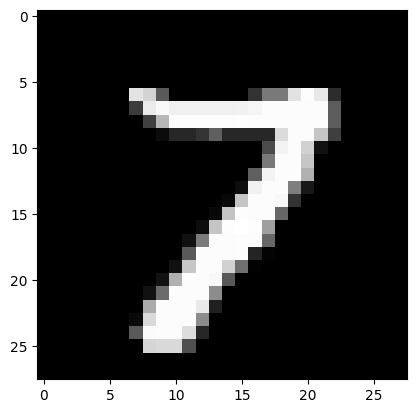

In [17]:
# Do evaluation

import matplotlib.pyplot as plt

model.eval() # set model in inference mode

data, target = test_data[34] # take a random test sample

data = data.unsqueeze(0).to(device) # unsqueeze means we are adding a batch dimension

output = model(data)

prediction = output.argmax(dim = 1, keepdim = True).item()

print(f'Prediction: {prediction}')

image = data.squeeze(0).squeeze(0).cpu().numpy() # unpack the image from the data, squeeze out channel dimensions

plt.imshow(image, cmap = 'gray') # colormap is gray
plt.show()